# 04 Presentation Figures

Review-only notebook for final report and presentation assets. Run `make assets` before opening this notebook so every display below comes from saved pipeline outputs.

In [1]:
from pathlib import Path
import shutil

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
SLIDES_DIR = FIGURES_DIR / "slides"
SLIDES_DIR.mkdir(parents=True, exist_ok=True)

figure_assets = [
    "primary_dag.png",
    "treatment_prevalence.png",
    "discovery_comparison.png",
    "overlap_plot.png",
    "subgroup_summary.png",
]
table_assets = [
    "cohort_flow.csv",
    "main_effect_estimates.csv",
    "robustness_summary.csv",
]

missing = [str(FIGURES_DIR / name) for name in figure_assets if not (FIGURES_DIR / name).exists()]
missing += [str(TABLES_DIR / name) for name in table_assets if not (TABLES_DIR / name).exists()]
if missing:
    raise FileNotFoundError("Run `make assets` first. Missing:\n" + "\n".join(missing))

## Final Figures

primary_dag.png


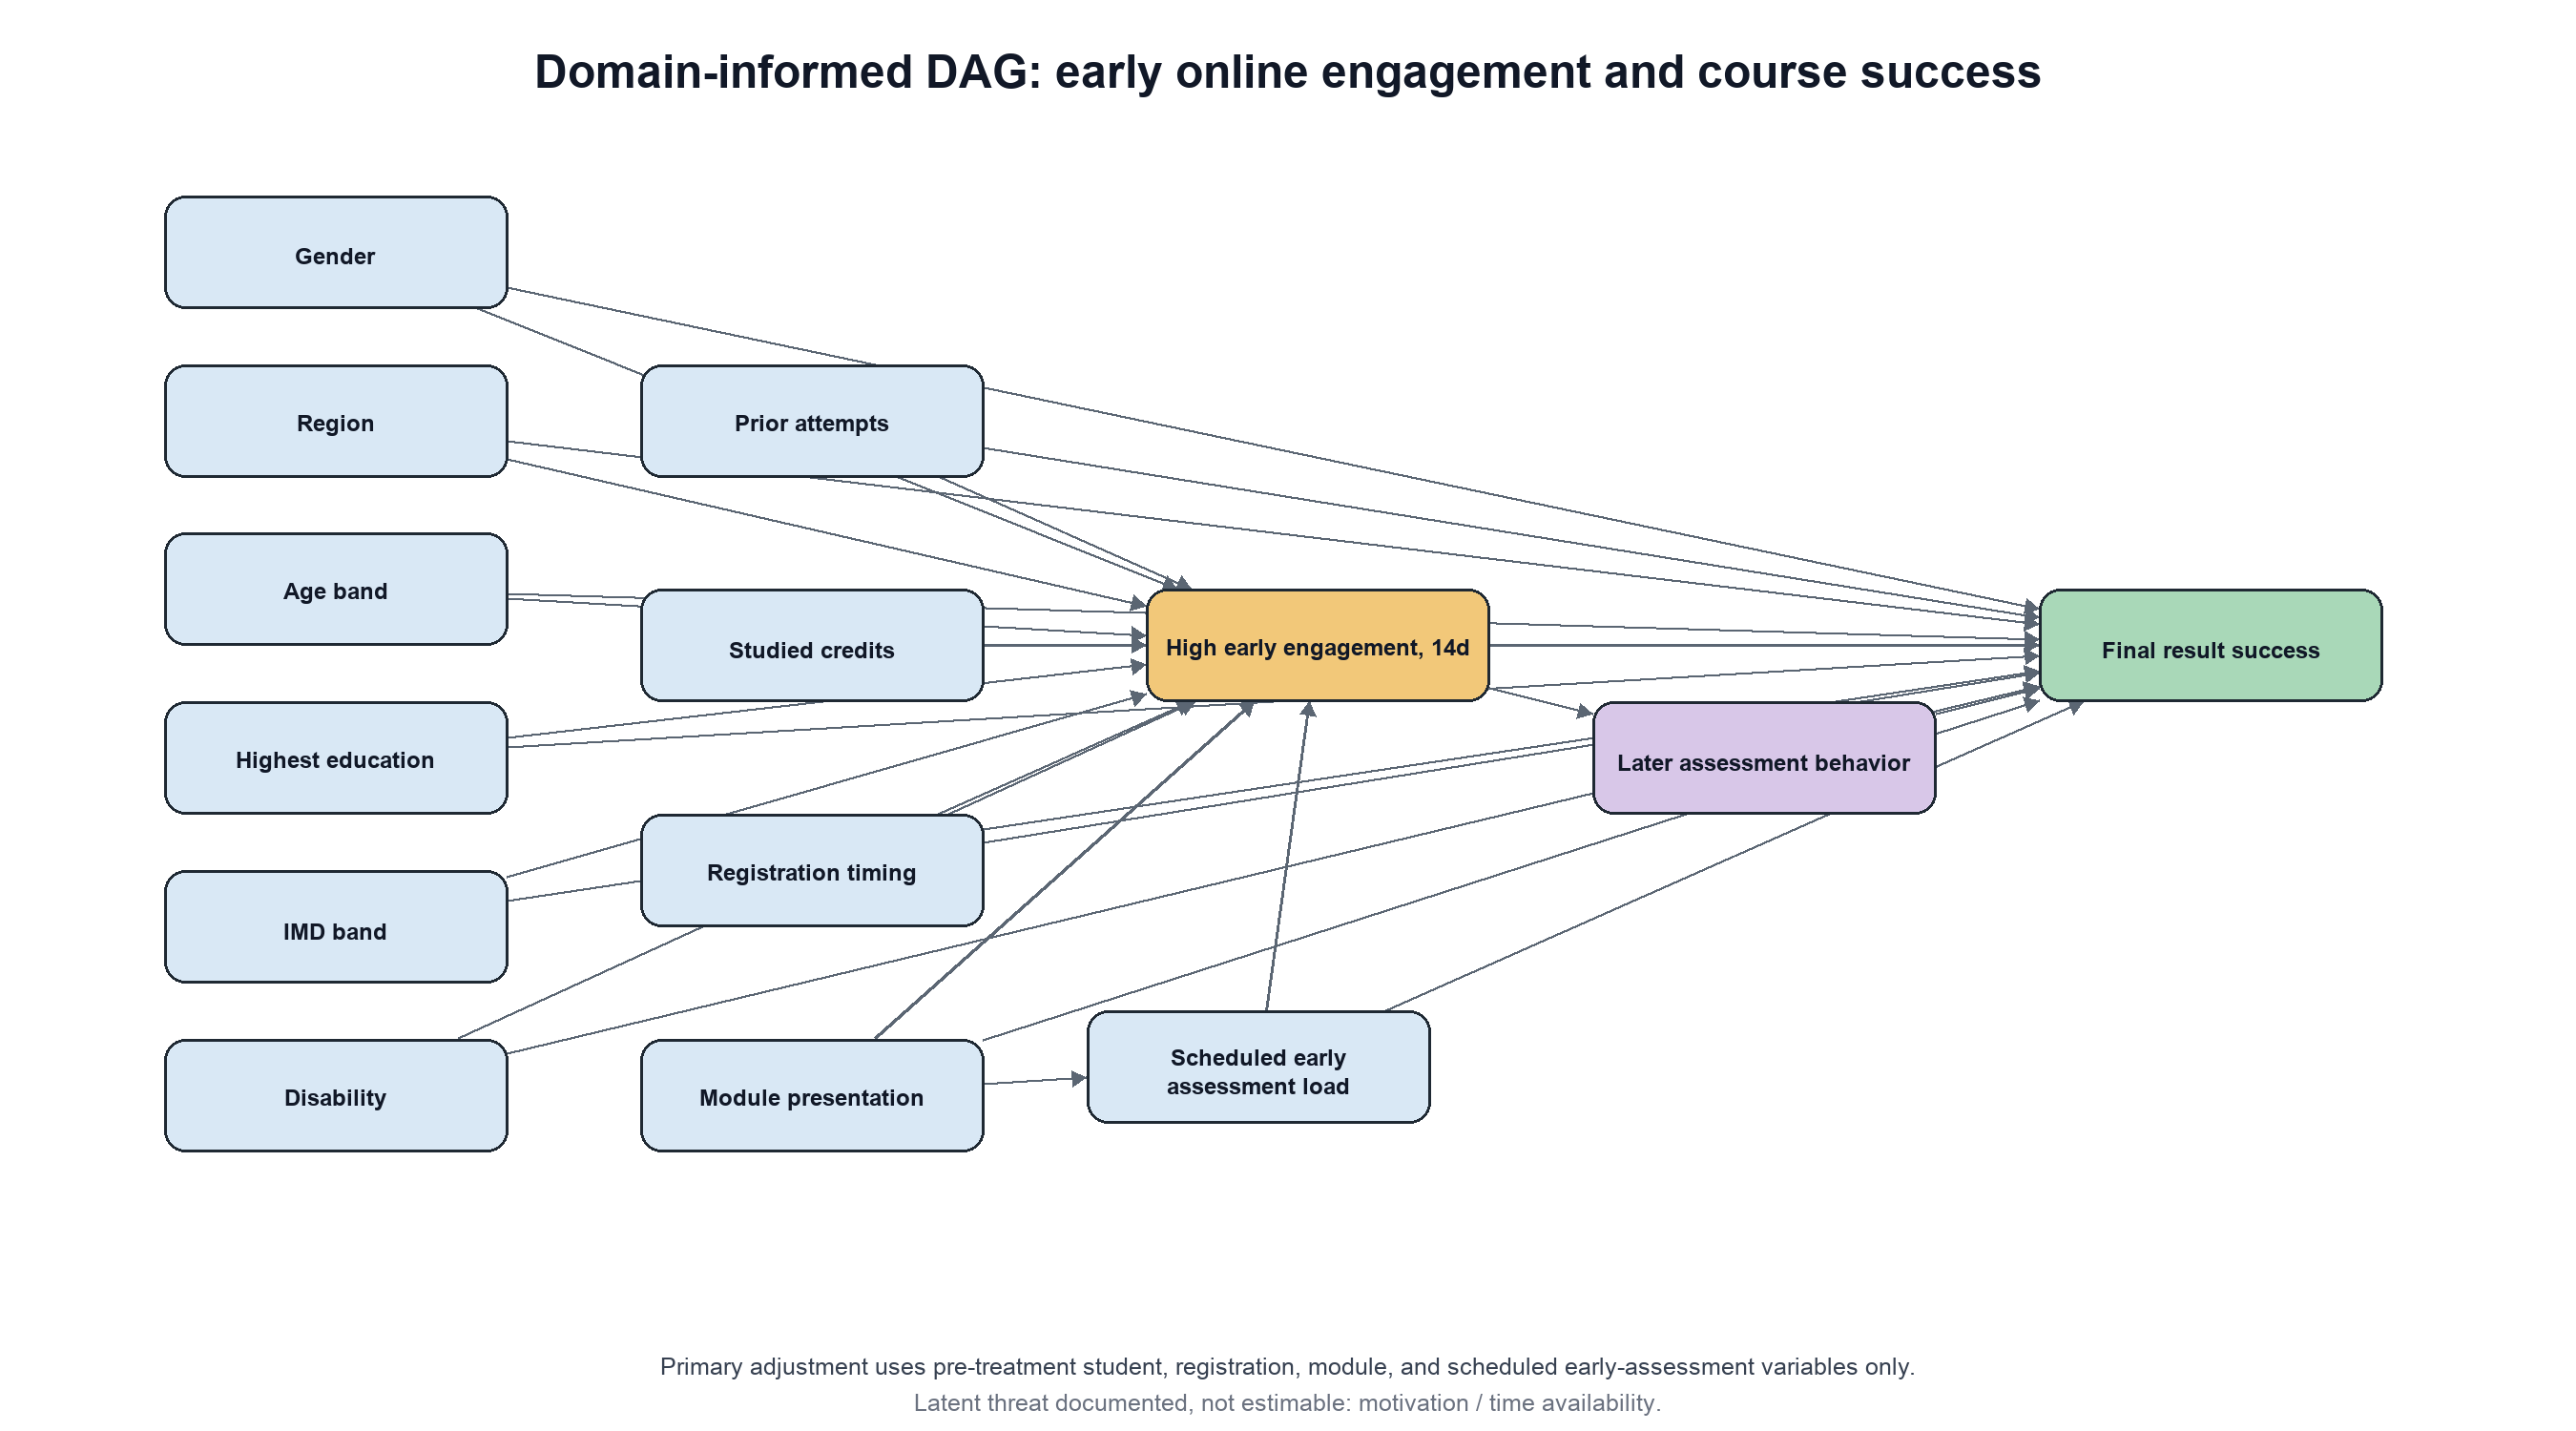

treatment_prevalence.png


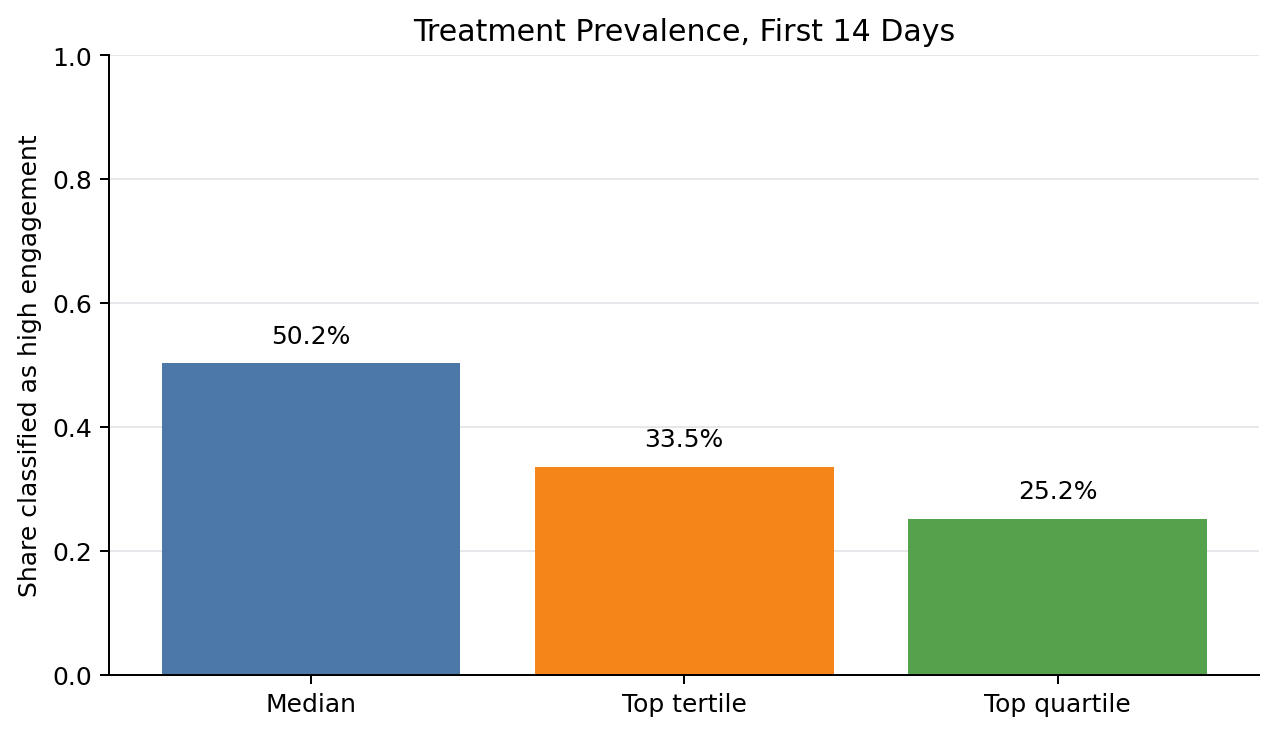

discovery_comparison.png


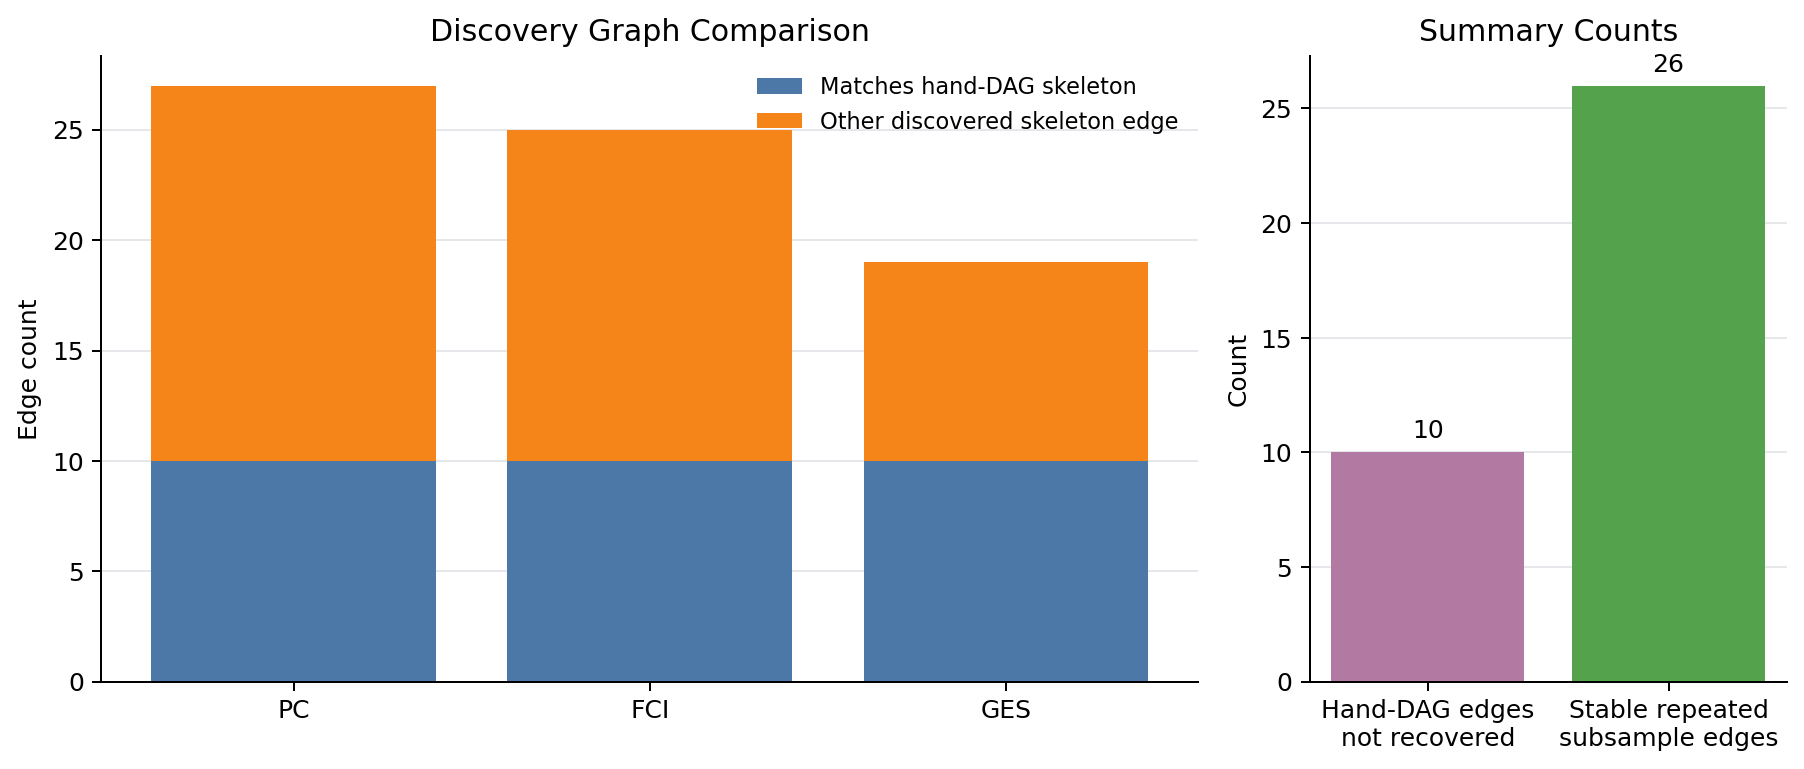

overlap_plot.png


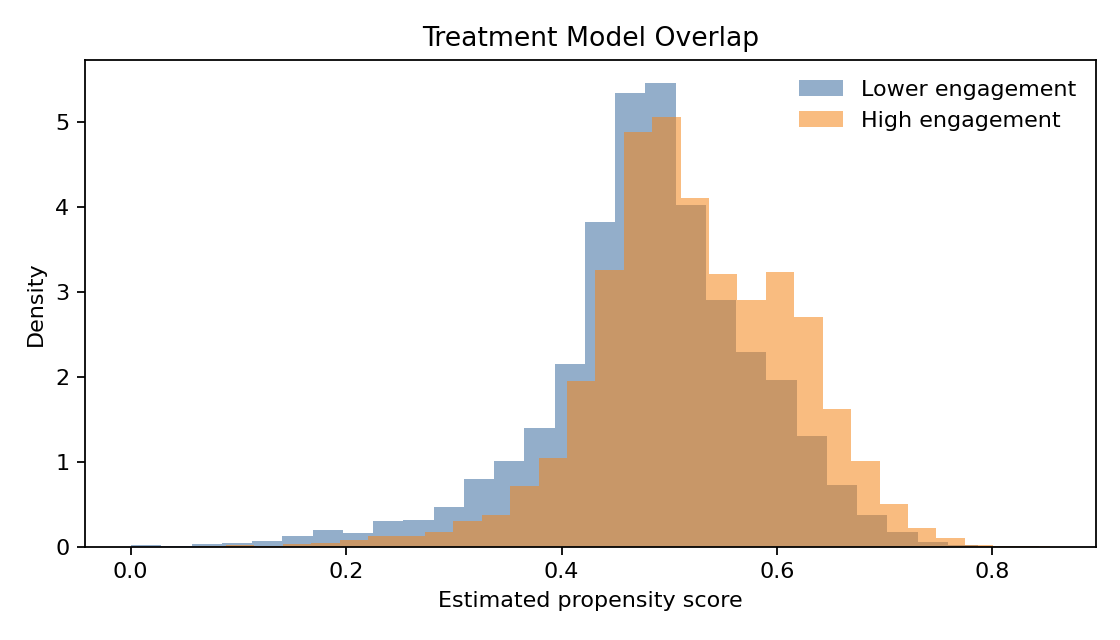

subgroup_summary.png


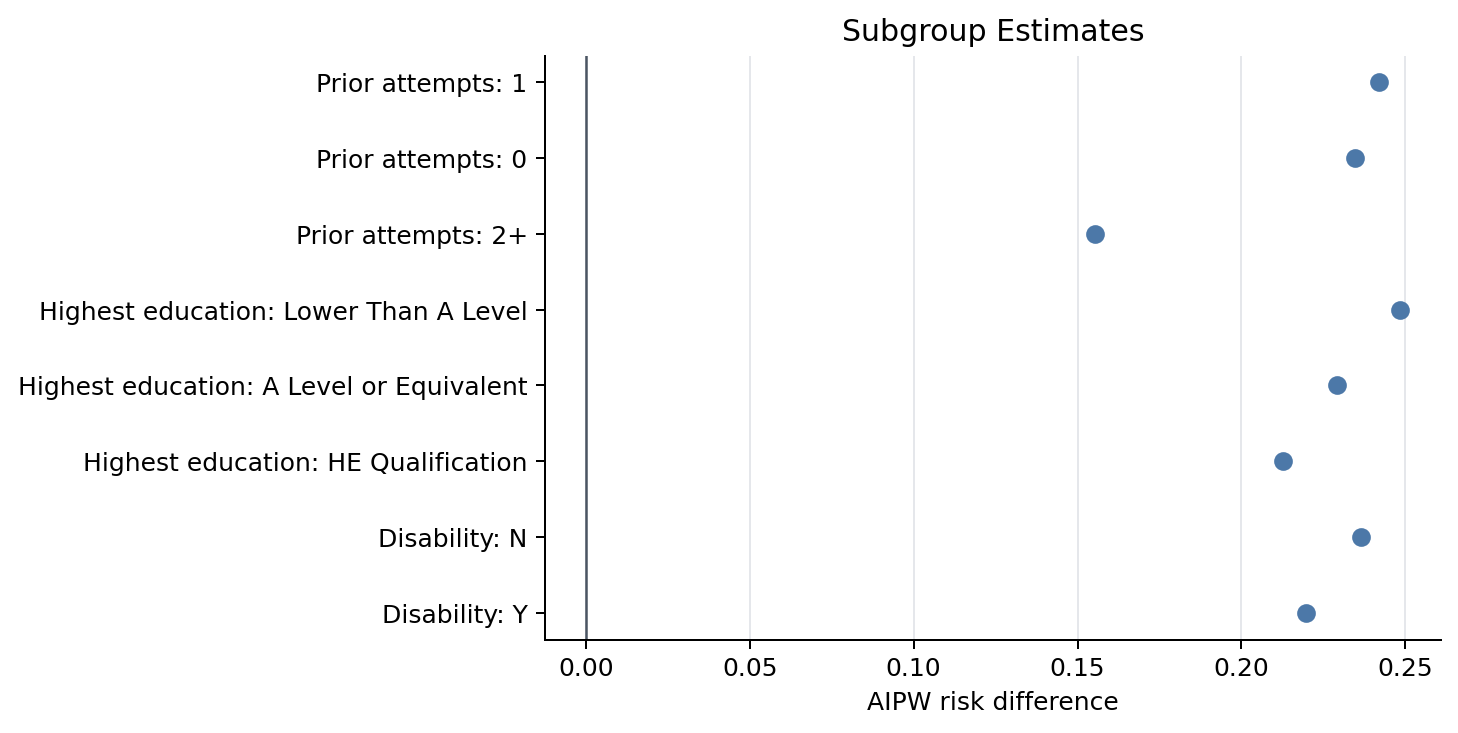

In [2]:
for name in figure_assets:
    print(name)
    display(Image(filename=str(FIGURES_DIR / name)))

## Final Tables

In [3]:
for name in table_assets:
    print(name)
    display(pd.read_csv(TABLES_DIR / name))

cohort_flow.csv


,Stage,Rows remaining,Excluded rows,Rule
0,Student info records,32593,0,studentInfo records loaded.
1,After required table joins,32593,0,Dropped records without registration or course...
2,After primary treatment eligibility,28128,4465,Dropped records with date_unregistration < 14;...


main_effect_estimates.csv


,Estimator,Preferred,Status,Risk difference,95% CI lower,95% CI upper,SE,Estimated treated mean,Estimated control mean,Analysis rows,Notes
0,Regression adjustment,No,success,0.234926,0.234157,0.235694,0.000392,0.663548,0.428623,28128.0,mean predicted potential outcome under separat...
1,Stabilized IPTW,No,success,0.233985,0.216530,0.251439,0.008905,0.662309,0.428325,28128.0,stabilized IPTW Hajek-style weighted mean cont...
2,AIPW,Yes,success,0.235260,0.224048,0.246471,0.005720,0.664047,0.428788,28128.0,doubly robust AIPW estimator using propensity ...
3,Nearest-neighbor matching,No,skipped,NaN,NaN,NaN,NaN,NaN,NaN,NaN,poor overlap diagnostics; matching estimate no...


robustness_summary.csv


,Window days,Threshold,Status,AIPW risk difference,Analysis rows,Treated rows,Control rows,Overlap flag
0,7,Median,success,0.203618,28128,14185,13943,Flagged
1,7,Top tertile,success,0.194479,28128,9461,18667,Flagged
2,7,Top quartile,success,0.196320,28128,7079,21049,Flagged
3,14,Median,success,0.235260,28128,14134,13994,Flagged
4,14,Top tertile,success,0.218716,28128,9429,18699,Flagged
5,14,Top quartile,success,0.218022,28128,7080,21048,Flagged
6,21,Median,success,0.236357,27913,14018,13895,Flagged
7,21,Top tertile,success,0.224888,27913,9335,18578,Flagged
8,21,Top quartile,success,0.219158,27913,7014,20899,Flagged


## Slide-Friendly Copies

In [4]:
for name in figure_assets:
    source = FIGURES_DIR / name
    destination = SLIDES_DIR / name
    shutil.copy2(source, destination)
    print(destination.relative_to(PROJECT_ROOT))

reports/figures/slides/primary_dag.png
reports/figures/slides/treatment_prevalence.png
reports/figures/slides/discovery_comparison.png
reports/figures/slides/overlap_plot.png
reports/figures/slides/subgroup_summary.png
